In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Dataset\Road.csv"
)

print(df.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Dataset\Road.csv"
)

df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [7]:
area_counts = df["Area_accident_occured"].value_counts()

area_counts

Area_accident_occured
Other                              3819
Office areas                       3451
Residential areas                  2060
 Church areas                      1060
 Industrial areas                   456
School areas                        415
  Recreational areas                327
 Outside rural areas                218
 Hospital areas                     121
  Market areas                       63
Rural village areas                  44
Unknown                              22
Rural village areasOffice areas      20
Recreational areas                    1
Name: count, dtype: int64

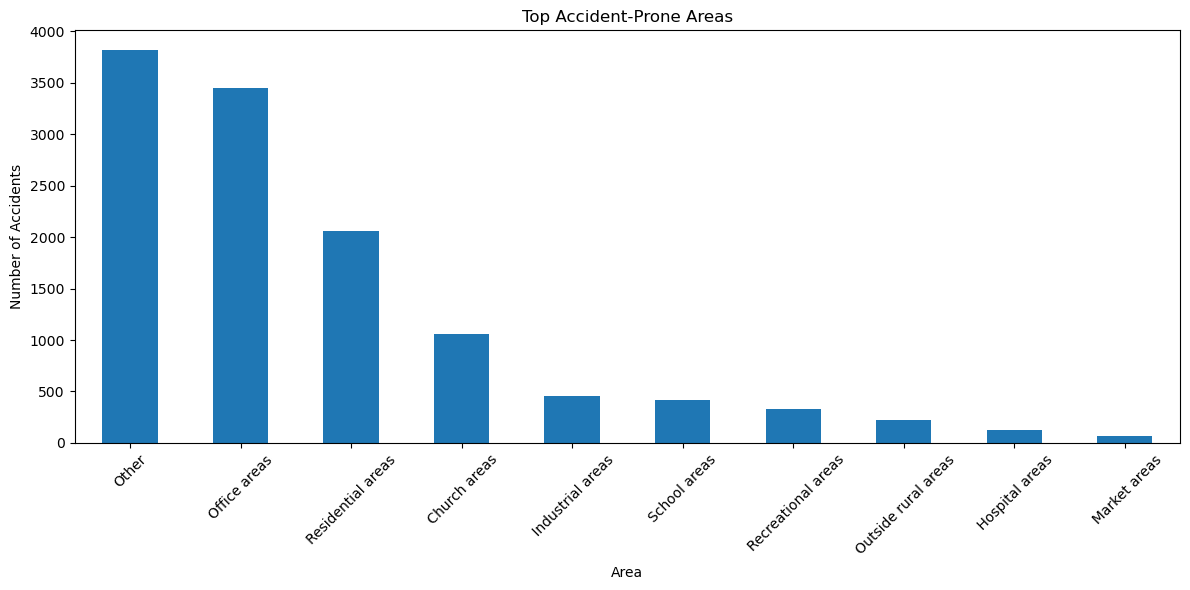

In [8]:
plt.figure(figsize=(12, 6))

area_counts.head(10).plot(kind="bar")

plt.title("Top Accident-Prone Areas")
plt.xlabel("Area")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
area_severity = pd.crosstab(
    df["Area_accident_occured"],
    df["Accident_severity"]
)

area_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Area_accident_occured,,,
Market areas,3,7,53
Recreational areas,8,39,280
Church areas,10,141,909
Hospital areas,0,12,109
Industrial areas,6,60,390
Outside rural areas,1,40,177
Office areas,39,475,2937
Other,43,546,3230
Recreational areas,0,1,0


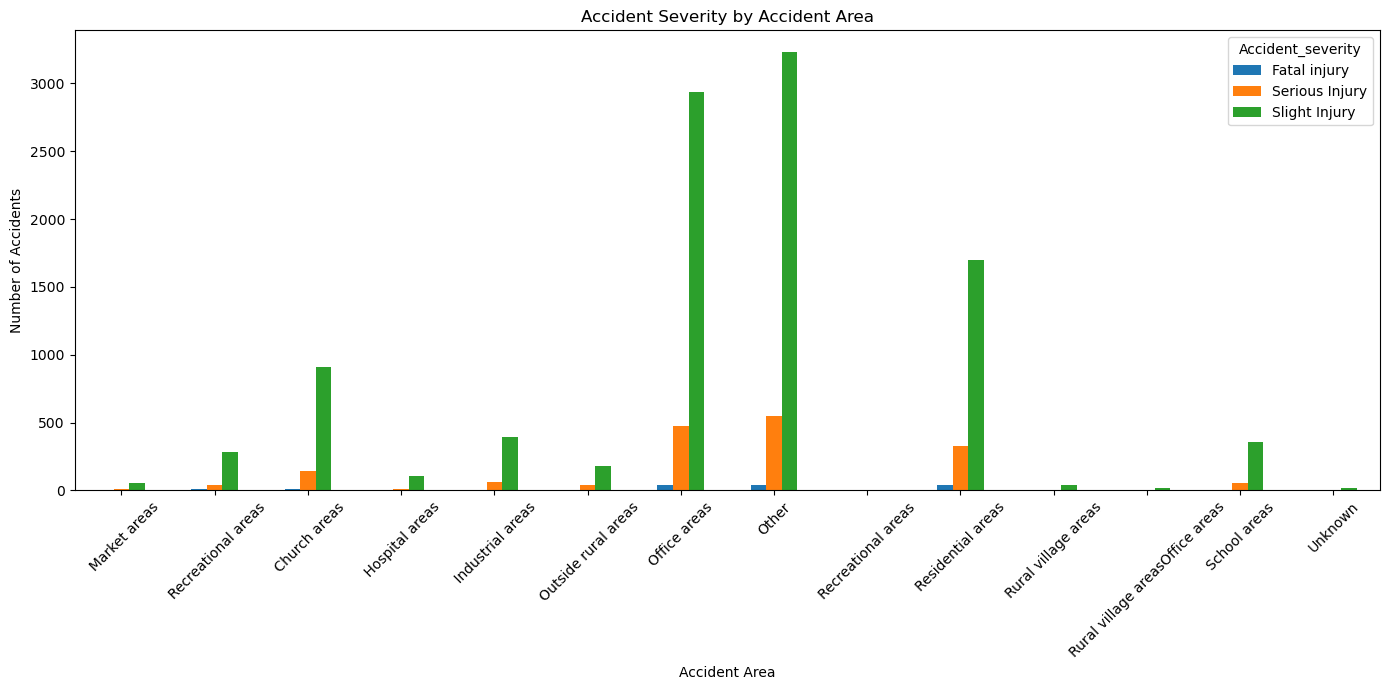

In [10]:
area_severity.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Accident Severity by Accident Area")
plt.xlabel("Accident Area")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
severity_weights = {
    "Slight Injury": 1,
    "Serious Injury": 2,
    "Fatal injury": 3
}

In [12]:
df["Severity_Score"] = df["Accident_severity"].map(
    severity_weights
)

In [13]:
area_risk = df.groupby(
    "Area_accident_occured"
)["Severity_Score"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

area_risk

,count,mean
Area_accident_occured,,
Recreational areas,1,2.000000
Rural village areasOffice areas,20,1.300000
Unknown,22,1.272727
Market areas,63,1.206349
Residential areas,2060,1.193204
Outside rural areas,218,1.192661
Recreational areas,327,1.168196
Other,3819,1.165488
Office areas,3451,1.160243


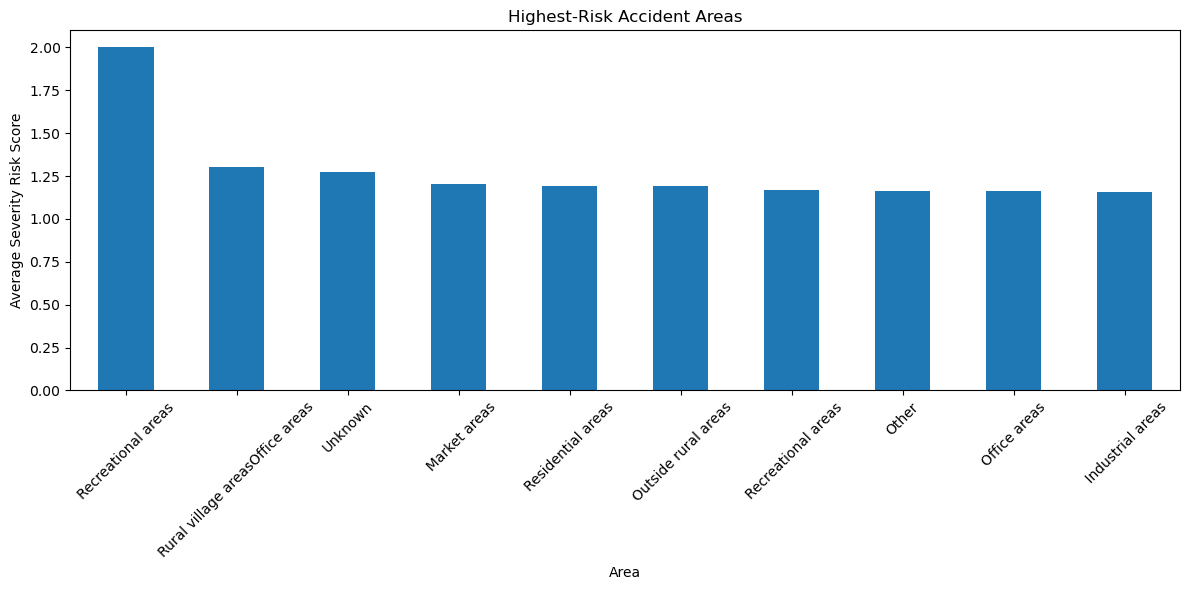

In [14]:
area_risk.head(10)["mean"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Highest-Risk Accident Areas")
plt.xlabel("Area")
plt.ylabel("Average Severity Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
junction_hotspots = pd.crosstab(
    df["Types_of_Junction"],
    df["Accident_severity"]
)

junction_hotspots

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Types_of_Junction,,,
Crossing,12,245,1920
No junction,71,581,3185
O Shape,1,26,137
Other,2,83,360
T Shape,0,7,53
Unknown,2,26,163
X Shape,0,0,12
Y Shape,53,633,3857


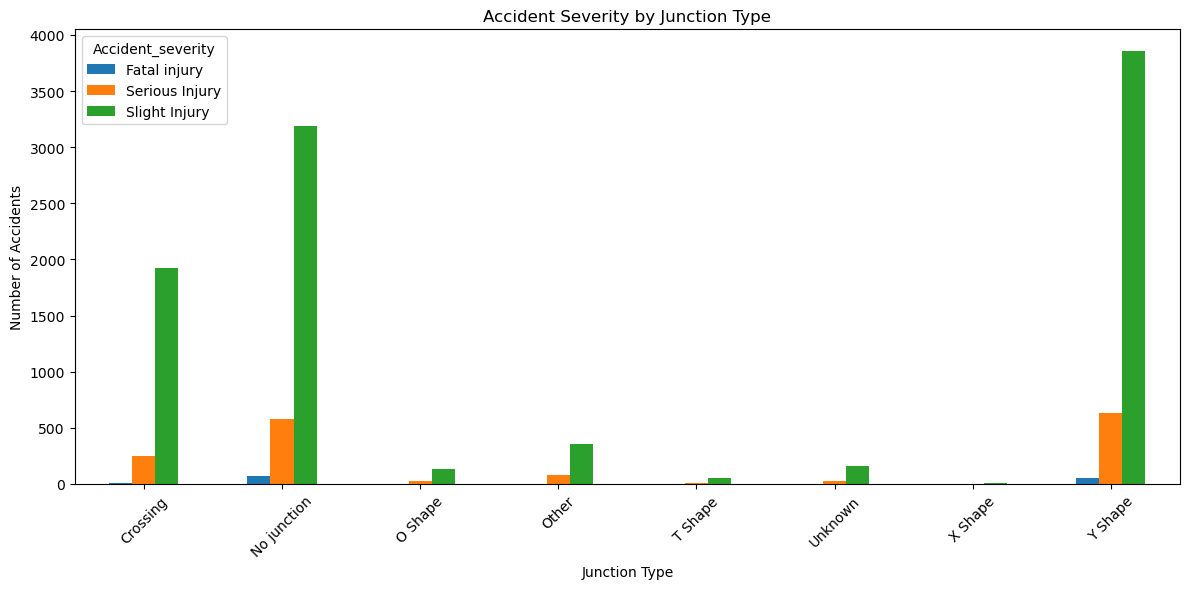

In [16]:
junction_hotspots.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Accident Severity by Junction Type")
plt.xlabel("Junction Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
area_risk.to_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\area_risk_analysis.csv"
)

In [19]:
area_severity.to_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\area_severity_analysis.csv"
)